In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Upload example data and see column types
data = pd.read_csv('datasets/cleaned_2022-12_data.csv')
data.dtypes

service_date                  object
route_id                       int64
direction_id                  object
half_trip_id                 float64
stop_id                        int64
time_point_id                 object
time_point_order               int64
point_type                    object
standard_type                 object
scheduled                     object
actual                        object
scheduled_headway            float64
headway                      float64
scheduled_datetime            object
actual_datetime               object
available_bus_depart_time     object
dtype: object

In [4]:
data[(data['route_id'] == 24) & (data['half_trip_id'] == 57743857)]

,service_date,route_id,direction_id,half_trip_id,stop_id,time_point_id,time_point_order,point_type,standard_type,scheduled,actual,scheduled_headway,headway,scheduled_datetime,actual_datetime,available_bus_depart_time
18396,2022-12-02,24,Inbound,57743857.0,185,matpn,4,Midpoint,Schedule,05:17:00,05:18:02,NaN,NaN,2022-12-02 05:17:00,2022-12-02 05:18:02,2022-12-02 05:18:02
18426,2022-12-02,24,Inbound,57743857.0,334,ashmt,8,Endpoint,Schedule,05:28:00,05:26:34,NaN,NaN,2022-12-02 05:28:00,2022-12-02 05:26:34,2022-12-02 05:59:05
18459,2022-12-02,24,Inbound,57743857.0,6411,wakav,1,Startpoint,Schedule,05:05:00,05:05:37,NaN,NaN,2022-12-02 05:05:00,2022-12-02 05:05:37,2022-12-02 05:05:37
18491,2022-12-02,24,Inbound,57743857.0,6419,logan,2,Midpoint,Schedule,05:07:00,05:08:10,NaN,NaN,2022-12-02 05:07:00,2022-12-02 05:08:10,2022-12-02 05:08:10
18523,2022-12-02,24,Inbound,57743857.0,6366,rivcm,3,Midpoint,Schedule,05:14:00,05:15:49,NaN,NaN,2022-12-02 05:14:00,2022-12-02 05:15:49,2022-12-02 05:15:49
18555,2022-12-02,24,Inbound,57743857.0,588,rvcen,5,Midpoint,Schedule,05:20:00,05:20:37,NaN,NaN,2022-12-02 05:20:00,2022-12-02 05:20:37,2022-12-02 05:20:37
18587,2022-12-02,24,Inbound,57743857.0,591,pierc,6,Midpoint,Schedule,05:22:00,05:24:17,NaN,NaN,2022-12-02 05:22:00,2022-12-02 05:24:17,2022-12-02 05:24:17
18619,2022-12-02,24,Inbound,57743857.0,533,dotga,7,Midpoint,Schedule,05:25:00,05:25:59,NaN,NaN,2022-12-02 05:25:00,2022-12-02 05:25:59,2022-12-02 05:25:59


In [5]:
# Combine all 2022 dataset
df1 = pd.read_csv('datasets/cleaned_2022-01_data.csv')
df2 = pd.read_csv('datasets/cleaned_2022-02_data.csv')
df3 = pd.read_csv('datasets/cleaned_2022-03_data.csv')
df4 = pd.read_csv('datasets/cleaned_2022-04_data.csv')
df5 = pd.read_csv('datasets/cleaned_2022-05_data.csv')
df6 = pd.read_csv('datasets/cleaned_2022-06_data.csv')
df7 = pd.read_csv('datasets/cleaned_2022-07_data.csv')
df8 = pd.read_csv('datasets/cleaned_2022-08_data.csv')
df9 = pd.read_csv('datasets/cleaned_2022-09_data.csv')
df10 = pd.read_csv('datasets/cleaned_2022-10_data.csv')
df11 = pd.read_csv('datasets/cleaned_2022-11_data.csv')
df12 = pd.read_csv('datasets/cleaned_2022-12_data.csv')
all_dfs = [df1, df2, df3, df4, df5, df6, df7, df8, df9, df10, df11, df12]  # List of DataFrames to concatenate  

# Concatenate all into 2022 DataFrame
combined_df_2022 = pd.concat(all_dfs, axis=0, ignore_index=True)

df19_1 = pd.read_csv('datasets/cleaned_2019-01-03_data.csv')
df19_2 = pd.read_csv('datasets/cleaned_2019-04-06_data.csv')
df19_3 = pd.read_csv('datasets/cleaned_2019-07-09_data.csv')
df19_4 = pd.read_csv('datasets/cleaned_2019-10-12_data.csv')

df_2019 = [df19_1, df19_2, df19_3, df19_4]

combined_df_2019 = pd.concat(df_2019, axis=0, ignore_index=True)

In [6]:
def ee(df):
    df['scheduled_datetime'] = pd.to_datetime(df['scheduled_datetime'])
    df['actual_datetime'] = pd.to_datetime(df['actual_datetime'])
    
    def calculate_end_to_end(df):
        scheduled_travel_time = (df['scheduled_datetime'].max() - df['scheduled_datetime'].min()).total_seconds() / 60
        actual_travel_time = (df['actual_datetime'].max() - df['actual_datetime'].min()).total_seconds() / 60
        return pd.Series({
            'scheduled_travel_time_minutes': scheduled_travel_time,
            'actual_travel_time_minutes': actual_travel_time
        })
    
    trip_travel_times = df.groupby(['service_date', 'route_id', 'half_trip_id']).apply(calculate_end_to_end).reset_index()
    
    daily_average_travel_times = trip_travel_times.groupby(['service_date', 'route_id']).agg({
        'scheduled_travel_time_minutes': 'mean',
        'actual_travel_time_minutes': 'mean'
    }).reset_index()
    
    return daily_average_travel_times

In [7]:
ee_2022 = ee(combined_df_2022)
ee_2022

C:\Users\mirua\AppData\Local\Temp\ipykernel_6308\489457873.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trip_travel_times = df.groupby(['service_date', 'route_id', 'half_trip_id']).apply(calculate_end_to_end).reset_index()


,service_date,route_id,scheduled_travel_time_minutes,actual_travel_time_minutes
0,2022-01-01,15,24.809160,21.833715
1,2022-01-01,17,16.312500,13.896875
2,2022-01-01,22,28.059322,23.996893
3,2022-01-01,23,26.917241,25.133793
4,2022-01-01,24,23.958333,24.287500
...,...,...,...,...
4757,2022-12-31,33,20.357143,21.302381
4758,2022-12-31,42,14.512500,13.627500
4759,2022-12-31,44,21.694444,21.783796
4760,2022-12-31,45,20.278481,21.326793


In [8]:
ee_2019 = ee(combined_df_2019)
ee_2019

C:\Users\mirua\AppData\Local\Temp\ipykernel_6308\489457873.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trip_travel_times = df.groupby(['service_date', 'route_id', 'half_trip_id']).apply(calculate_end_to_end).reset_index()


,service_date,route_id,scheduled_travel_time_minutes,actual_travel_time_minutes
0,2019-01-01,15,24.720721,23.810511
1,2019-01-01,17,13.750000,15.039583
2,2019-01-01,22,27.897436,27.215670
3,2019-01-01,23,25.742188,27.903646
4,2019-01-01,24,24.166667,26.909028
...,...,...,...,...
5269,2019-12-31,33,25.209302,22.406589
5270,2019-12-31,42,16.363636,13.790909
5271,2019-12-31,44,26.000000,23.678571
5272,2019-12-31,45,27.940171,24.889459


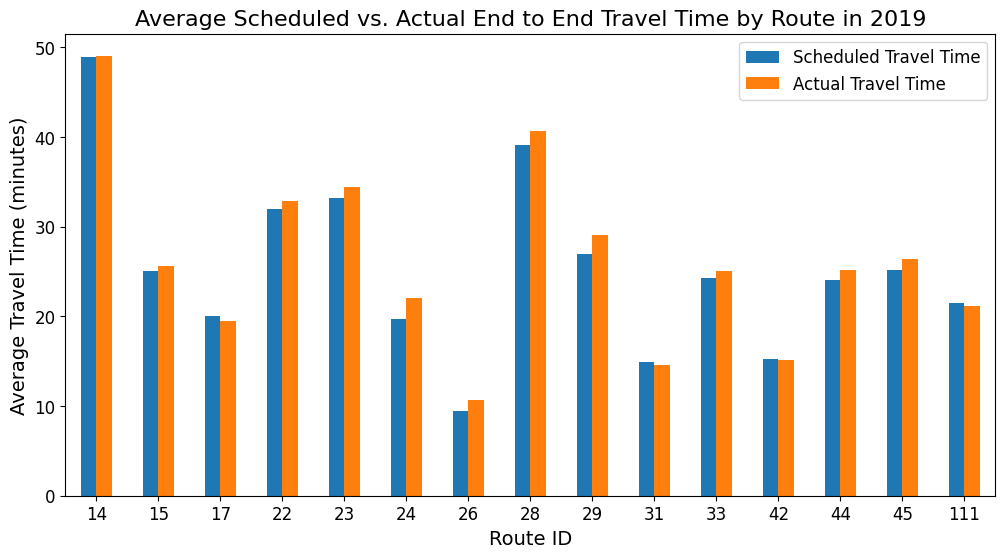

In [9]:
# Calculate overall averages per route
route_avg_end_to_end_2019 = ee_2019.groupby('route_id')[['scheduled_travel_time_minutes', 'actual_travel_time_minutes']].mean().reset_index()

# Plot bar plot
route_avg_end_to_end_2019.plot(x='route_id', kind='bar', figsize=(12, 6))
plt.xlabel('Route ID', fontsize=14)
plt.ylabel('Average Travel Time (minutes)', fontsize=14)
plt.title('Average Scheduled vs. Actual End to End Travel Time by Route in 2019', fontsize=16)
plt.legend(['Scheduled Travel Time', 'Actual Travel Time'], fontsize=12)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.show()

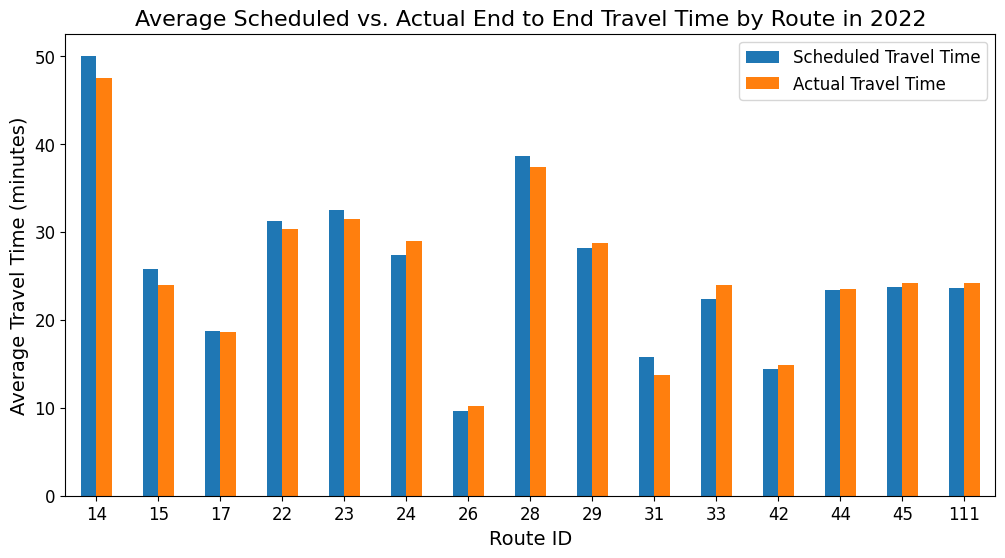

In [12]:
# Calculate overall averages per route
route_avg_end_to_end_2022 = ee_2022.groupby('route_id')[['scheduled_travel_time_minutes', 'actual_travel_time_minutes']].mean().reset_index()

# Plot bar plot
route_avg_end_to_end_2022.plot(x='route_id', kind='bar', xfigsize=(12, 6))
plt.xlabel('Route ID', fontsize=14)
plt.ylabel('Average Travel Time (minutes)', fontsize=14)
plt.title('Average Scheduled vs. Actual End to End Travel Time by Route in 2022', fontsize=16)
plt.legend(['Scheduled Travel Time', 'Actual Travel Time'], fontsize=12)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [10]:
# Calculate average travel times for each route in 2019
avg_travel_2019 = ee_2019.groupby('route_id')[['scheduled_travel_time_minutes', 'actual_travel_time_minutes']].mean().reset_index()

# Calculate average travel times for each route in 2022
avg_travel_2022 = ee_2022.groupby('route_id')[['scheduled_travel_time_minutes', 'actual_travel_time_minutes']].mean().reset_index()

# Merge the two DataFrames on 'route_id' to align the data
travel_time_comparison = pd.merge(avg_travel_2019, avg_travel_2022, on='route_id', suffixes=('_2019', '_2022'))

# Calculate the difference between 2022 and 2019
travel_time_comparison['scheduled_time_change'] = travel_time_comparison['scheduled_travel_time_minutes_2022'] - travel_time_comparison['scheduled_travel_time_minutes_2019']
travel_time_comparison['actual_time_change'] = travel_time_comparison['actual_travel_time_minutes_2022'] - travel_time_comparison['actual_travel_time_minutes_2019']

# Display the results
travel_time_comparison[['route_id', 'scheduled_travel_time_minutes_2019', 'scheduled_travel_time_minutes_2022', 'actual_travel_time_minutes_2019', 'actual_travel_time_minutes_2022', 'scheduled_time_change', 'actual_time_change']]

,route_id,scheduled_travel_time_minutes_2019,scheduled_travel_time_minutes_2022,actual_travel_time_minutes_2019,actual_travel_time_minutes_2022,scheduled_time_change,actual_time_change
0,14,48.882765,50.025014,49.069835,47.540234,1.142250,-1.529601
1,15,25.071752,25.797861,25.605558,23.931664,0.726110,-1.673895
2,17,20.049698,18.737250,19.434394,18.574591,-1.312448,-0.859803
3,22,31.984919,31.246713,32.873310,30.305775,-0.738206,-2.567535
4,23,33.178854,32.448950,34.477326,31.461099,-0.729904,-3.016226
5,24,19.710332,27.407881,22.105863,28.949767,7.697549,6.843904
6,26,9.497249,9.636938,10.631703,10.181339,0.139689,-0.450364
7,28,39.082621,38.582579,40.664224,37.331464,-0.500042,-3.332759
8,29,26.923215,28.170241,29.023263,28.680709,1.247026,-0.342554
9,31,14.920812,15.803741,14.527325,13.703218,0.882929,-0.824106
